# Final stage of the preprocessing pipeline

This notebook takes the dataframe $\texttt{df\_eligible\_reduced2}$ and performs a complete imputation of all missing values, preparing a fully clean dataset ready to be used as input for the predictive models. For that end, we'll take into account the correlation matrix given in the previous notebook, because that gives us an understanding of which columns were more aligned with others.

Based on this information:
+ We use simple distribution‑based imputations for variables that behave independently
+ We use dedicated imputation functions for those that show strong correlations.

In the second case (e.g., $\texttt{primary\_tumor}$ with $\texttt{catheter\_device}$, or $\texttt{pTNM\_stage}$ with $\texttt{tumor\_surgically\_removed}$), the imputations rely on joint and conditional probability distributions so that the filled‑in values remain consistent with the empirical relationships observed in the data.

The dataframe that outputs from this notebook is therefore fully imputed and consistent, and it will be the one passed directly into the modeling pipeline.

# Read the data

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path_data = "dataframes/df_eligible_reduced2.csv"
df = pd.read_csv(path_data)

path_traits = "dataframes/df_traits_reduced2.csv"
df_traits = pd.read_csv(path_traits)

In [3]:
n_rows, n_columns = df.shape
print("Rows: ", n_rows)
print("Columns: ", n_columns)

Rows:  395
Columns:  42


### Delete rows with VTE nan

Because we want to predict VTE, it wouldn’t make any sense to fill in VTE NaN values, because doing so would leak outcome information into the model and artificially distort the true distribution of the target variable. This is why, instead, we remove and drop the patients that have the predictive variable missing.

We'll also drop the variables $\texttt{VTE\_recurrence}$ and $\texttt{vte\_concomitant\_cancer\_dx}$, because, by definition, they are directly correlated with wether the patient had a VTE during the study:

In [4]:
removed = df["VTE"].isna().sum()
print("Rows removed:", removed)
df = df.dropna(subset=["VTE"]).reset_index(drop=True)

Rows removed: 4


In [5]:
for t in ["VTE_recurrence", "vte_concomitant_cancer_dx"]:
    row = df_traits.loc[df_traits["trait"] == t, "definition"].iloc[0]
    print(f"{t}:\n{row}\n")

VTE_recurrence:
Whether patient suffered VTE recurrence along 12 months of follow-up

vte_concomitant_cancer_dx:
Was VTE diagnosed at the same time or following to cancer diagnosis?



In [6]:
# Drop VTE_recurrence and vte_concomitant_cancer_dx
df = df.drop(columns=["VTE_recurrence"])
df = df.drop(columns=["vte_concomitant_cancer_dx"])

Now, let's see if we can drop some patients because of their high number of nan values. For that, we print the top 10 patients with more missing vriables on our dataset $\texttt{df}$.

In [7]:
nan_counts = df.isna().sum(axis=1).sort_values(ascending=False)

top10 = pd.DataFrame({
    "rank": ["top1", "top2", "top3", "top4", "top5", "top6", "top7", "top8", "top9", "top10"],
    "n_missing": nan_counts.iloc[:10].values
})

top10

,rank,n_missing
0,top1,13
1,top2,13
2,top3,13
3,top4,13
4,top5,12
5,top6,12
6,top7,12
7,top8,12
8,top9,12
9,top10,12


As we can see, out of 43 columns, all the patients have 13 or less missing values. As it is $<\frac{13}{43}\times100\sim30\%$, it's decided to keep them, having into consideration that we already have few patients. In conclusion, we don't drop any rows for having an excessive amout of nan values.

# Fill in the nan values

### How many nan values are there?

First, we'll see again which are the data types of the variables remaining on our final dataset.

In [8]:
from utils import table_types_unique

table = table_types_unique(df)
table

,column,type,distinct_values
0,age_cancer_dx,numeric,53
1,bmi,numeric,312
2,performance_status,numeric,3
3,grade_histological_differentiation,numeric,3
4,rs11696364_n_risk_alleles,numeric,3
5,rs169713_n_risk_alleles,numeric,3
6,rs4524_n_risk_alleles,numeric,3
7,rs6003_n_risk_alleles,numeric,3
8,rs2227631_n_risk_alleles,numeric,3
9,rs268_n_risk_alleles,numeric,2


All columns are numeric. However, let's remember that we have encoded (via one-hot-encoding) the columns of $\texttt{tobacco\_use}$ and $\texttt{primary\_tumor}$. Because of that, first we are going to check if those columns have nans or not, because they are going to be filled taking into account their characteristics.

In [9]:
# One-hot-encoding and categorical variables
# For the one-hot-encoding columns, a nan value is interpreted as if all columns from the encoding are 0

cols_tobacco = [c for c in df.columns if c.startswith("tobacco_use")]
nans_tobacco = (df[cols_tobacco].sum(axis=1) == 0).sum()

cols_tumor = [c for c in df.columns if c.startswith("primary_tumor")]
nans_tumor = (df[cols_tumor].sum(axis=1) == 0).sum()

print("Nan values (rows) in tobacco_use:", nans_tobacco)
print("Nan values (rows) in primary_tumor:", nans_tumor)

Nan values (rows) in tobacco_use: 13
Nan values (rows) in primary_tumor: 1


The function $\texttt{num\_nans}$ computes a summary table where each row corresponds to a dataframe column and reports the number of distinct non‑missing values and the total count of missing (NaN) entries for that column. We will use it to check whether the nan values are being filled, and what columns are left to do.

In [10]:
from utils import num_nans

table_num = num_nans(df)

# Remove one‑hot encoded columns
table_num = table_num[
    ~table_num["column"].str.startswith(("tobacco_use", "primary_tumor"))
]

# Keep only the rows where the column has at least one NaN
table_num = table_num[table_num["nan"] > 0]
table_num

,column,distinct_values,nan
2,performance_status,3,5
3,grade_histological_differentiation,3,153
4,rs11696364_n_risk_alleles,3,62
5,rs169713_n_risk_alleles,3,62
6,rs4524_n_risk_alleles,3,62
7,rs6003_n_risk_alleles,3,62
8,rs2227631_n_risk_alleles,3,62
9,rs268_n_risk_alleles,2,62
10,rs5110_n_risk_alleles,3,62
11,rs6025_n_risk_alleles,2,62


To fill in the nan values from all of these columns, we are going to take into account the correlation matrix, so it has more sense than to just put the mode or a median. For those variables that have no high correlation with others, we use the function $\texttt{impute\_with\_distribution}$, that is simply filling in the nan values with a probability distribution.

In [11]:
from utils import impute_with_distribution

#### $\texttt{performance\_status}$

Because of the correlation plot from, we see that it correlates more with $\texttt{pTNM\_stage}$ and $\texttt{tumor\_surgically\_removed}$, but still, it's a very low correlation. We'll fill in the nan values following a probability distribution.

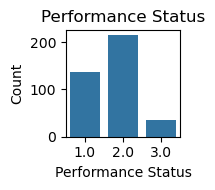

In [12]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="performance_status")

plt.title("Performance Status")
plt.xlabel("Performance Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
df = impute_with_distribution(df, "performance_status")

Number of NaN values in performance_status: 0


#### $\texttt{grade\_histological\_differentiation}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

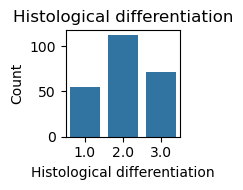

In [14]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="grade_histological_differentiation")

plt.title("Histological differentiation")
plt.xlabel("Histological differentiation")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [15]:
df = impute_with_distribution(df, "grade_histological_differentiation")

Number of NaN values in grade_histological_differentiation: 0


#### $\texttt{n\_risk\_alleles}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

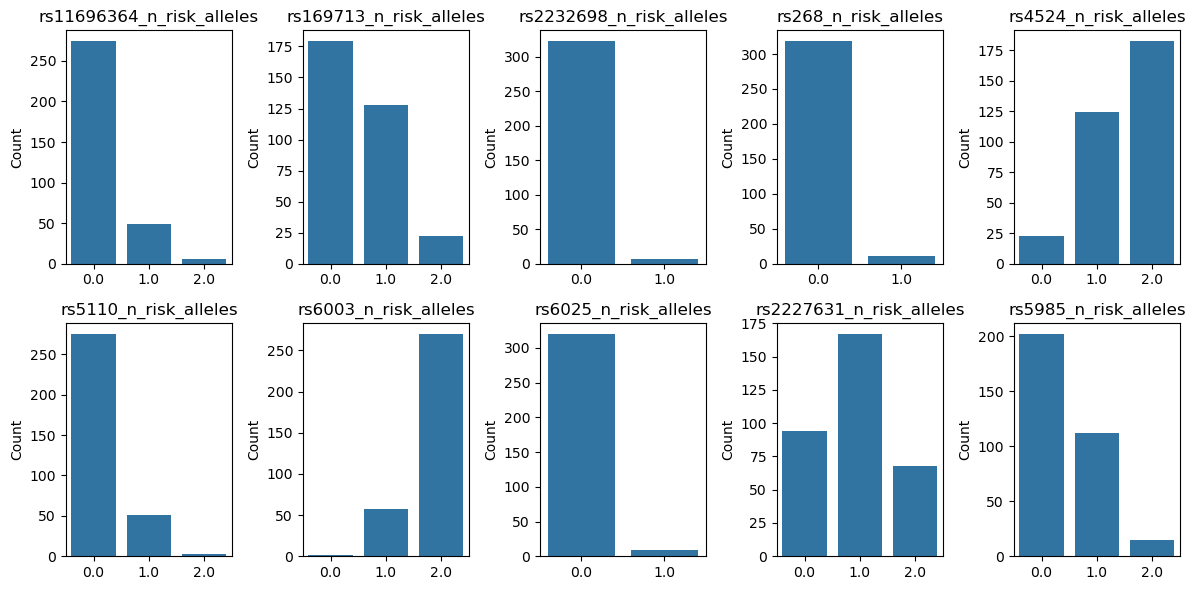

In [16]:
cols = [
    "rs11696364_n_risk_alleles",
    "rs169713_n_risk_alleles",
    "rs2232698_n_risk_alleles",
    "rs268_n_risk_alleles",
    "rs4524_n_risk_alleles",
    "rs5110_n_risk_alleles",
    "rs6003_n_risk_alleles",
    "rs6025_n_risk_alleles",
    "rs2227631_n_risk_alleles",
    "rs5985_n_risk_alleles"
]

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [17]:
for col in cols:
    df = impute_with_distribution(df, col)

Number of NaN values in rs11696364_n_risk_alleles: 0
Number of NaN values in rs169713_n_risk_alleles: 0
Number of NaN values in rs2232698_n_risk_alleles: 0
Number of NaN values in rs268_n_risk_alleles: 0
Number of NaN values in rs4524_n_risk_alleles: 0
Number of NaN values in rs5110_n_risk_alleles: 0
Number of NaN values in rs6003_n_risk_alleles: 0
Number of NaN values in rs6025_n_risk_alleles: 0
Number of NaN values in rs2227631_n_risk_alleles: 0
Number of NaN values in rs5985_n_risk_alleles: 0


#### $\texttt{pTNM\_stage}$ and $\texttt{tumor\_surgically\_removed}$

Because $\texttt{pTNM\_stage}$ and $\texttt{tumor\_surgically\_removed}$ are correlated variables, we impute their missing values jointly using the function $\texttt{impute\_stage\_and\_surgery}$, which samples replacements from the observed joint and conditional probability distributions to preserve the real dependency structure between both variables.

In [18]:
from utils import impute_stage_and_surgery

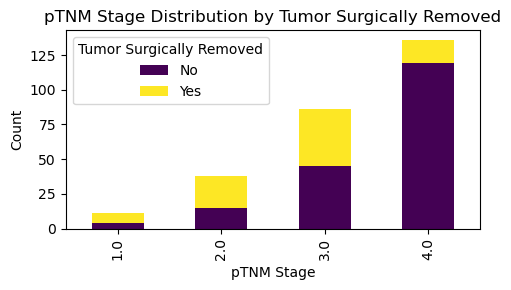

In [19]:
col_stage = "pTNM_stage"
col_removed = "tumor_surgically_removed"

ct = pd.crosstab(df[col_stage], df[col_removed])

ct.plot(kind="bar", stacked=True, figsize=(5,3), colormap="viridis")
plt.title("pTNM Stage Distribution by Tumor Surgically Removed")
plt.xlabel("pTNM Stage")
plt.ylabel("Count")
plt.legend(title="Tumor Surgically Removed", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

As said before, this code imputes missing values in $\texttt{pTNM\_stage}$ and $\texttt{tumor\_surgically\_removed}$ by sampling from their joint and conditional probability distributions, ensuring that the imputed values preserve the real relationship between the two variables.

In [20]:
df = impute_stage_and_surgery(
    df,
    col_stage="pTNM_stage",
    col_removed="tumor_surgically_removed"
)

print("Remaining NaNs in pTNM_stage:", df[col_stage].isna().sum())
print("Remaining NaNs in tumor_surgically_removed:", df[col_removed].isna().sum())

Remaining NaNs in pTNM_stage: 0
Remaining NaNs in tumor_surgically_removed: 0


#### $\texttt{chronic\_cardiac\_insufficiency}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

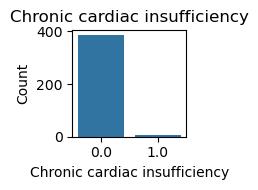

In [21]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="chronic_cardiac_insufficiency")

plt.title("Chronic cardiac insufficiency")
plt.xlabel("Chronic cardiac insufficiency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [22]:
df = impute_with_distribution(df, "chronic_cardiac_insufficiency")

Number of NaN values in chronic_cardiac_insufficiency: 0


#### $\texttt{copd}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

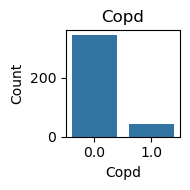

In [23]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="copd")

plt.title("Copd")
plt.xlabel("Copd")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [24]:
df = impute_with_distribution(df, "copd")

Number of NaN values in copd: 0


#### $\texttt{renal\_insufficiency}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

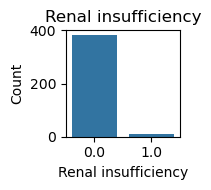

In [25]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="renal_insufficiency")

plt.title("Renal insufficiency")
plt.xlabel("Renal insufficiency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [26]:
df = impute_with_distribution(df, "renal_insufficiency")

Number of NaN values in renal_insufficiency: 0


#### $\texttt{arterial\_hypertension}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

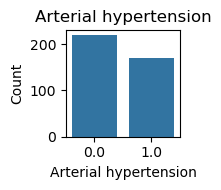

In [27]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="arterial_hypertension")

plt.title("Arterial hypertension")
plt.xlabel("Arterial hypertension")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [28]:
df = impute_with_distribution(df, "arterial_hypertension")

Number of NaN values in arterial_hypertension: 0


#### $\texttt{diabetes\_mellitus}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

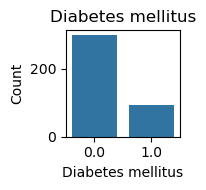

In [29]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="diabetes_mellitus")

plt.title("Diabetes mellitus")
plt.xlabel("Diabetes mellitus")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [30]:
df = impute_with_distribution(df, "diabetes_mellitus")

Number of NaN values in diabetes_mellitus: 0


#### $\texttt{dyslipidemia}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

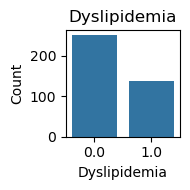

In [31]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="dyslipidemia")

plt.title("Dyslipidemia")
plt.xlabel("Dyslipidemia")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [32]:
df = impute_with_distribution(df, "dyslipidemia")

Number of NaN values in dyslipidemia: 0


#### $\texttt{hormone\_therapy}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

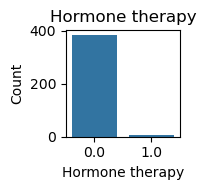

In [33]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="hormone_therapy")

plt.title("Hormone therapy")
plt.xlabel("Hormone therapy")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [34]:
df = impute_with_distribution(df, "hormone_therapy")

Number of NaN values in hormone_therapy: 0


#### $\texttt{previous\_vte}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

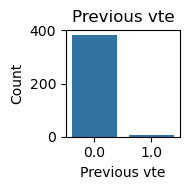

In [35]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="previous_vte")

plt.title("Previous vte")
plt.xlabel("Previous vte")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [36]:
df = impute_with_distribution(df, "previous_vte")

Number of NaN values in previous_vte: 0


#### $\texttt{venous\_insufficiency}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

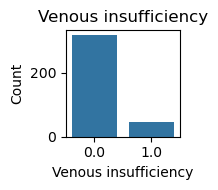

In [37]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="venous_insufficiency")

plt.title("Venous insufficiency")
plt.xlabel("Venous insufficiency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
df = impute_with_distribution(df, "venous_insufficiency")

Number of NaN values in venous_insufficiency: 0


#### $\texttt{family\_background\_vte}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution.

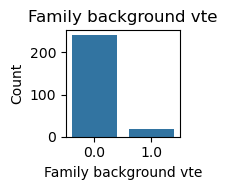

In [39]:
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="family_background_vte")

plt.title("Family background vte")
plt.xlabel("Family background vte")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [40]:
df = impute_with_distribution(df, "family_background_vte")

Number of NaN values in family_background_vte: 0


#### $\texttt{catheter\_device}$ and $\texttt{primary\_tumor}$

In this case, the variables $\texttt{primary\_tumor}$ (a one‑hot encoded tumor site) and $\texttt{catheter\_device}$ are clinically correlated, so missing values cannot be imputed independently; instead, we use the function $\texttt{impute\_primary\_and\_catheter}$ to sample replacements from the observed joint and conditional probability distributions, ensuring that the imputed tumor category and catheter status remain consistent with the real patterns in the data.

In [41]:
from utils import impute_primary_and_catheter

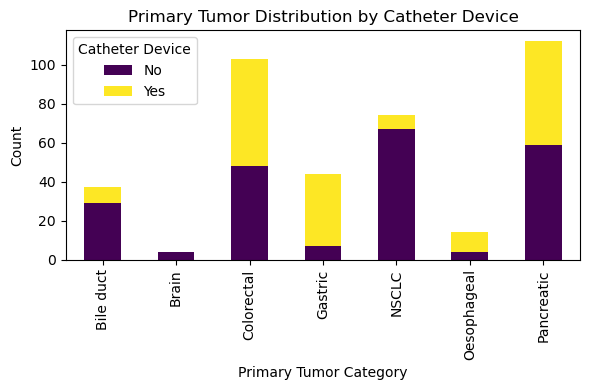

In [42]:
primary_cols = [
    "primary_tumor_Bile duct",
    "primary_tumor_Brain",
    "primary_tumor_Colorectal",
    "primary_tumor_Gastric",
    "primary_tumor_NSCLC",
    "primary_tumor_Oesophageal",
    "primary_tumor_Pancreatic"
]

short_labels = [
    "Bile duct",
    "Brain",
    "Colorectal",
    "Gastric",
    "NSCLC",
    "Oesophageal",
    "Pancreatic"
]

ct = pd.DataFrame(index=primary_cols, columns=[0, 1], data=0)

for col in primary_cols:
    ct.loc[col, 0] = len(df[(df[col] == 1) & (df["catheter_device"] == 0)])
    ct.loc[col, 1] = len(df[(df[col] == 1) & (df["catheter_device"] == 1)])

ct.index = short_labels

ct.plot(kind="bar", stacked=True, figsize=(6, 4), colormap="viridis")
plt.title("Primary Tumor Distribution by Catheter Device")
plt.xlabel("Primary Tumor Category")
plt.ylabel("Count")
plt.legend(title="Catheter Device", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

In [43]:
df = impute_primary_and_catheter(
    df,
    primary_cols=primary_cols,
    catheter_col="catheter_device"
)

print("Remaining NaNs in catheter_device:", df["catheter_device"].isna().sum())
print("Rows with no primary tumor selected:", (df[primary_cols].sum(axis=1) == 0).sum())
print("Rows with multiple primary tumors:", (df[primary_cols].sum(axis=1) > 1).sum())

Remaining NaNs in catheter_device: 0
Rows with no primary tumor selected: 0
Rows with multiple primary tumors: 0


#### $\texttt{tobacco\_use}$

Doesn't correlate with any other variables in a high level $\rightarrow$ we'll fill in the nan values following the probability distribution. Because this is one of the previous categorical variables, we are going to use another function from utils: $\texttt{impute\_onehot\_with\_distribution}$.

In [44]:
from utils import impute_onehot_with_distribution

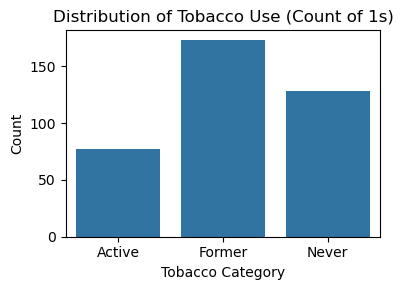

In [45]:
tobacco_cols = [
    "tobacco_use_Active smoker",
    "tobacco_use_Former smoker",
    "tobacco_use_Never has smoked"
]

# Plot distribution of existing 1s
counts = df[tobacco_cols].sum()
short_labels = ["Active", "Former", "Never"]
counts.index = short_labels

plt.figure(figsize=(4,3))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Distribution of Tobacco Use (Count of 1s)")
plt.ylabel("Count")
plt.xlabel("Tobacco Category")
plt.tight_layout()
plt.show()

In [46]:
# Impute missing one-hot rows
df = impute_onehot_with_distribution(df, tobacco_cols)

# Check correctness
check = df[tobacco_cols].sum(axis=1)
print("Rows with zero 1s:", (check == 0).sum())
print("Rows with more than one 1:", (check > 1).sum())

Rows with zero 1s: 0
Rows with more than one 1: 0


## Check nan values

Let's check wether there are still nan values left.

In [47]:
cols_tobacco = [c for c in df.columns if c.startswith("tobacco_use")]
num_filas_tobacco = (df[cols_tobacco].sum(axis=1) == 0).sum()

cols_tumor = [c for c in df.columns if c.startswith("primary_tumor")]
num_filas_tumor = (df[cols_tumor].sum(axis=1) == 0).sum()

print("Nan rows in tobacco_use:", num_filas_tobacco)
print("Nan rows in primary_tumor:", num_filas_tumor)

Nan rows in tobacco_use: 0
Nan rows in primary_tumor: 0


In [48]:
table_num = num_nans(df)

# Remove one‑hot encoded columns
table_num = table_num[
    ~table_num["column"].str.startswith(("tobacco_use", "primary_tumor"))
]

# Keep only the rows where the column has at least one NaN
table_num = table_num[table_num["nan"] > 0]
table_num

,column,distinct_values,nan


## Save $\texttt{df}$ to $\texttt{.csv}$

In [49]:
df.to_csv(
    "dataframes/df_ready.csv",
    index=False
)